# Anomaly Detection on NYC Taxi Demand
## Rolling Z-Score vs. STL Decomposition — A Method Comparison

---

### Problem

NYC taxi demand follows strong daily and weekly patterns: busy afternoons, quiet nights, weekend spikes. Anomalies in this dataset are **not** sudden spikes or sensor glitches — they are **slow-onset demand shifts** that last several days (holidays, storms). This makes detection hard:

- A method that looks for sharp z-score jumps will miss a gradual 30% demand drop over a holiday week.
- A method that ignores daily/weekly seasonality will flag every quiet weeknight as anomalous.
- Standard point-wise evaluation (precision/recall per 30-minute step) heavily penalizes any method that does not flag *every* point inside a 4-day anomaly window — even if it correctly raises an alarm on day 1.

**This notebook shows how two method choices (z-score vs. STL) and two evaluation choices (point-wise vs. window-wise) interact — and how the combination changes which method appears to win.**

---
## 1. Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from statsmodels.tsa.seasonal import STL
from sklearn.metrics import precision_score, recall_score, f1_score
import json
import warnings
warnings.filterwarnings('ignore')

# ── style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#0f1117',
    'axes.edgecolor':   '#2a2d3a',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.6,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

SURFACE  = '#0f1117'
C_SERIES = '#58a6ff'   # blue — single series (no legend needed)
C_ANOM   = '#f85149'   # red  — anomaly windows
C_BASE   = '#58a6ff'   # blue — baseline method
C_STL    = '#3fb950'   # green — STL method
C_MUTED  = '#8b949e'   # muted text / grid

In [2]:
df = pd.read_csv('../data/raw/nyc_taxi.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

with open('../data/raw/nab_labels.json') as f:
    labels = json.load(f)

raw_windows = labels['realKnownCause/nyc_taxi.csv']
windows = [(pd.Timestamp(w[0]), pd.Timestamp(w[1])) for w in raw_windows]
window_causes = [
    'NYC Marathon / Sandy anniv.',
    'Thanksgiving',
    'Christmas',
    'New Year',
    'Winter storm Juno',
]

# point-level ground truth
gt = np.zeros(len(df), dtype=int)
for start, end in windows:
    gt[(df['timestamp'] >= start) & (df['timestamp'] <= end)] = 1

print(f'Observations : {len(df):,}')
print(f'Time range   : {df.timestamp.min().date()} → {df.timestamp.max().date()}')
print(f'Anomaly pts  : {gt.sum():,}  ({gt.mean()*100:.1f}%)')
print(f'Normal pts   : {(gt==0).sum():,}  ({(gt==0).mean()*100:.1f}%)')

Observations : 10,320
Time range   : 2014-07-01 → 2015-01-31
Anomaly pts  : 1,035  (10.0%)
Normal pts   : 9,285  (90.0%)


### 1.1 Full time series with labeled anomaly windows

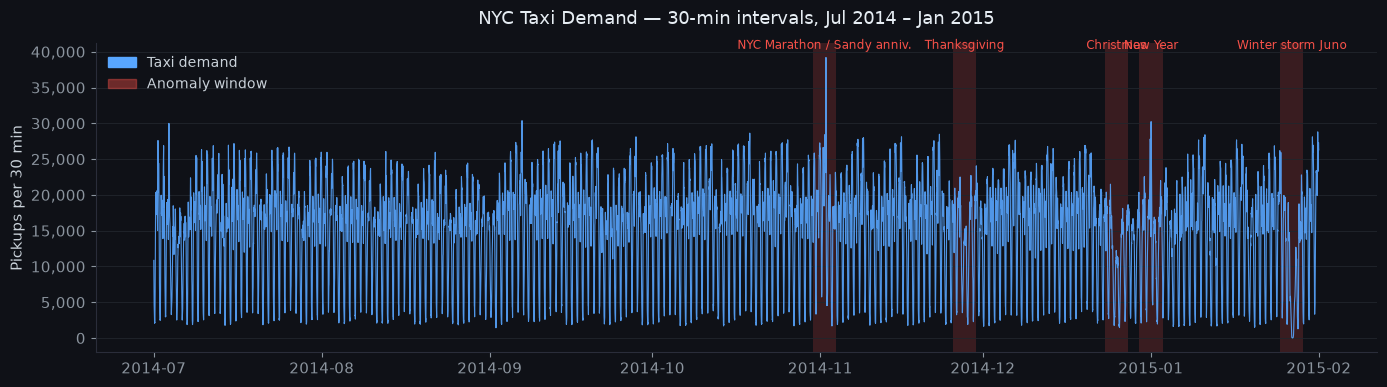

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df['timestamp'], df['value'], lw=0.8, color=C_SERIES, alpha=0.9)

for (start, end), cause in zip(windows, window_causes):
    ax.axvspan(start, end, alpha=0.18, color=C_ANOM, lw=0)
    ax.text(start + (end - start) / 2, df['value'].max() * 1.02,
            cause, ha='center', va='bottom', fontsize=8.5,
            color=C_ANOM, rotation=0)

ax.set_title('NYC Taxi Demand — 30-min intervals, Jul 2014 – Jan 2015',
             fontsize=13, pad=14, color='#e6edf3')
ax.set_ylabel('Pickups per 30 min')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y')

series_patch = mpatches.Patch(color=C_SERIES, label='Taxi demand')
anom_patch   = mpatches.Patch(color=C_ANOM,   alpha=0.4, label='Anomaly window')
ax.legend(handles=[series_patch, anom_patch], loc='upper left',
          framealpha=0, labelcolor='#c9d1d9', fontsize=10)

fig.tight_layout()
plt.savefig('../visualizations/01_timeseries_overview.png',
            dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()

---
## 2. Method 1 — Rolling Z-Score (Baseline)

For each point, compute a z-score against a **past-only 14-day rolling window** (672 steps). Points where |z| > 2.0 are flagged as anomalies.

**Why past-only?** A centered window includes the anomaly days themselves in the mean, shrinking their z-score toward zero and suppressing detection.

**Implementation note (bug fixed during independent verification):** `pandas.rolling()` includes the current observation in the window, so a plain `.rolling(N).mean()` is NOT truly past-only. `shift(1)` is applied before `.rolling()` to exclude the current point from its own window.

**Why this still struggles:** Holiday demand drops gradually over several days. By day 3 of a holiday, the rolling mean has already started shifting downward — the z-score for each individual point within the window stays below the threshold even though the entire period is anomalous.

In [4]:
LOOKBACK = 48 * 14   # 14 days
THRESH   = 2.0

# shift(1): truly past-only — current point excluded from its own window
shifted     = df['value'].shift(1)
roll_mean   = shifted.rolling(LOOKBACK, min_periods=48).mean()
roll_std    = shifted.rolling(LOOKBACK, min_periods=48).std().fillna(1).replace(0, 1)
zscore      = (df['value'] - roll_mean) / roll_std
pred_zscore = (np.abs(zscore) > THRESH).astype(int)

print(f'Points flagged by baseline : {pred_zscore.sum()}')

Points flagged by baseline : 55


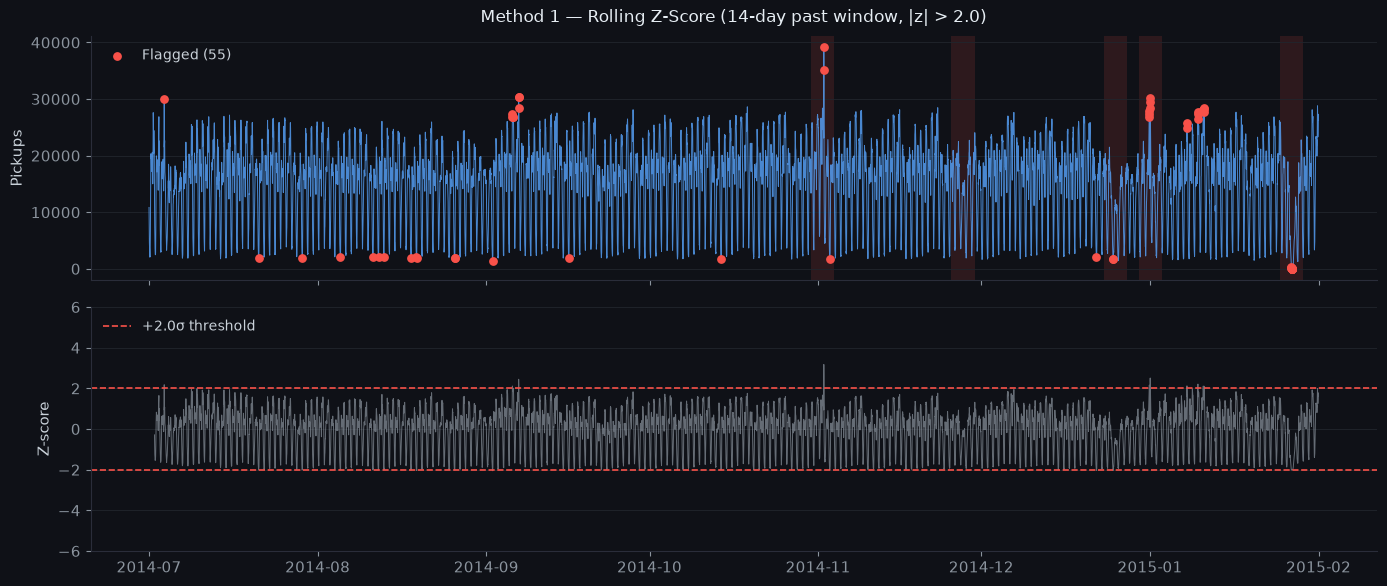

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# top: raw series + flags
ax1.plot(df['timestamp'], df['value'], lw=0.7, color=C_SERIES, alpha=0.8)
for start, end in windows:
    ax1.axvspan(start, end, alpha=0.13, color=C_ANOM, lw=0)
flagged = df['timestamp'][pred_zscore == 1]
ax1.scatter(flagged, df['value'][pred_zscore == 1],
            s=28, color=C_ANOM, zorder=3, label=f'Flagged ({len(flagged)})')
ax1.set_ylabel('Pickups')
ax1.set_title('Method 1 — Rolling Z-Score (14-day past window, |z| > 2.0)',
              fontsize=12, pad=10, color='#e6edf3')
ax1.legend(loc='upper left', framealpha=0, fontsize=10)
ax1.grid(axis='y')

# bottom: z-score
ax2.plot(df['timestamp'], zscore, lw=0.7, color=C_MUTED, alpha=0.7)
ax2.axhline( THRESH, color=C_ANOM, lw=1.2, ls='--', label=f'+{THRESH}σ threshold')
ax2.axhline(-THRESH, color=C_ANOM, lw=1.2, ls='--')
ax2.set_ylabel('Z-score')
ax2.set_ylim(-6, 6)
ax2.legend(loc='upper left', framealpha=0, fontsize=10)
ax2.grid(axis='y')

fig.tight_layout()
plt.savefig('../visualizations/02_baseline_zscore.png',
            dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()

---
## 3. Method 2 — STL Decomposition + Residual Z-Score

**STL (Seasonal and Trend decomposition using Loess)** separates the series into three components:

- **Trend** — slow long-term movement
- **Seasonal** — repeating daily (period=48) and weekly pattern
- **Residual** — what remains after removing trend and seasonality

Anomaly detection runs only on the residual, so normal patterns (quiet nights, busy Friday afternoons) no longer inflate z-scores. `robust=False` is intentional: robust mode down-weights outliers when fitting the seasonal component, which shrinks residuals for holiday periods and reduces sensitivity.

Threshold is applied to the global residual standard deviation (not a rolling window), because holidays affect the series across the full span and a rolling window would again adapt.

In [6]:
stl    = STL(df['value'], period=48, seasonal=7*48+1, robust=False)
result = stl.fit()

resid    = pd.Series(result.resid, index=df.index)
resid_z  = resid / resid.std()
pred_stl = (np.abs(resid_z) > THRESH).astype(int)

print(f'Points flagged by STL : {pred_stl.sum()}')

Points flagged by STL : 622


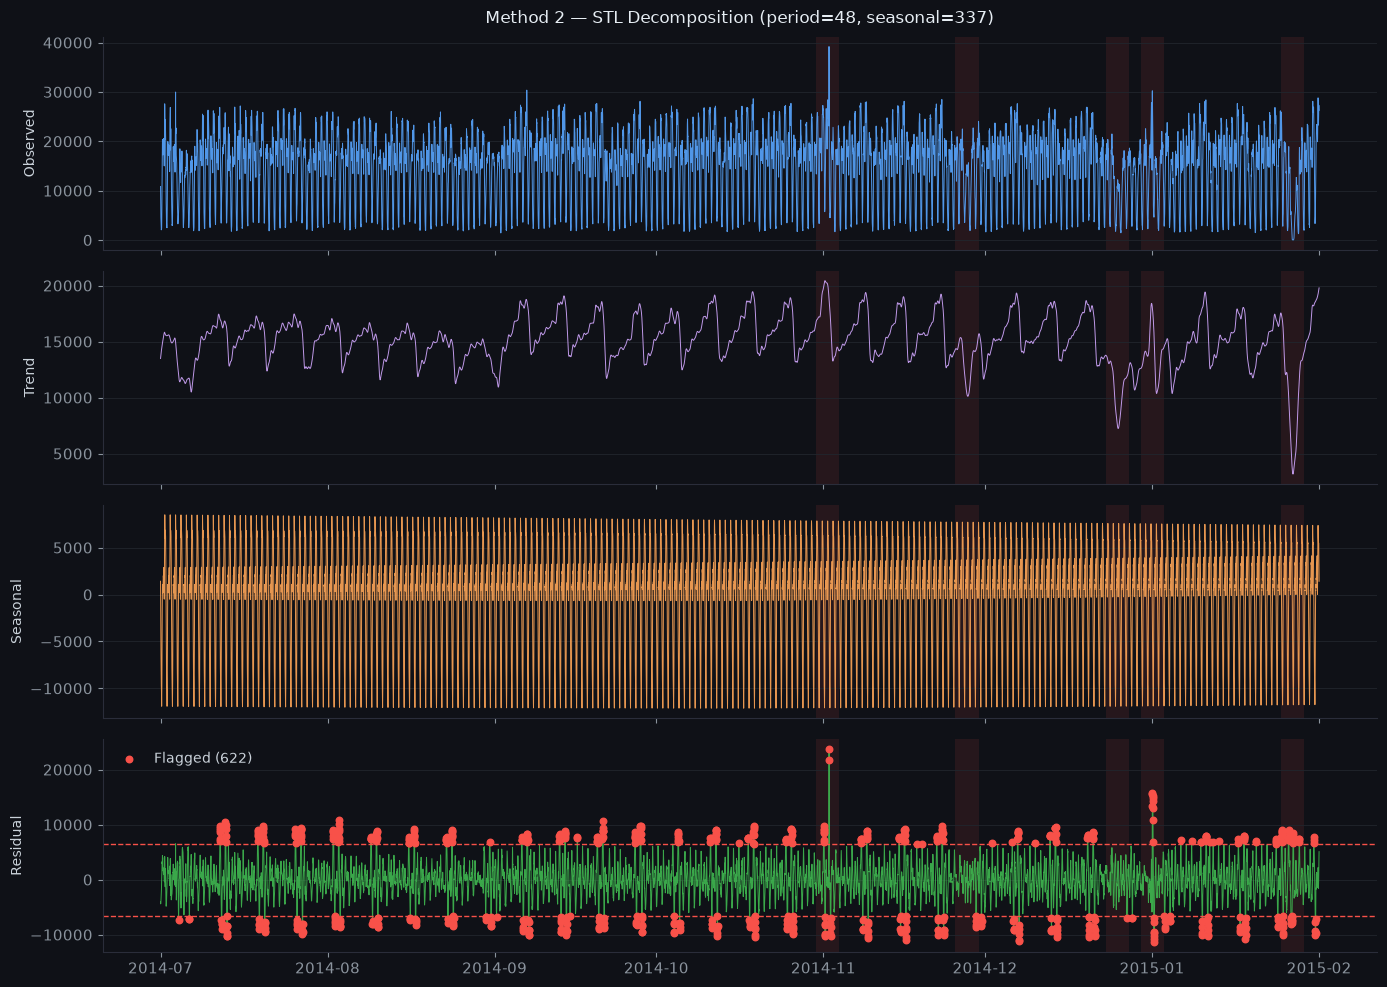

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

components = [
    (df['value'],        'Observed',  C_SERIES),
    (result.trend,       'Trend',     '#d2a8ff'),
    (result.seasonal,    'Seasonal',  '#ffa657'),
    (resid,              'Residual',  C_STL),
]

for ax, (series, label, color) in zip(axes, components):
    ax.plot(df['timestamp'], series, lw=0.7, color=color, alpha=0.9)
    for start, end in windows:
        ax.axvspan(start, end, alpha=0.10, color=C_ANOM, lw=0)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(axis='y')

# overlay flagged points on residual panel
ax_res = axes[3]
ax_res.scatter(df['timestamp'][pred_stl == 1], resid[pred_stl == 1],
               s=22, color=C_ANOM, zorder=3, label=f'Flagged ({pred_stl.sum()})')
ax_res.axhline( THRESH * resid.std(), color=C_ANOM, lw=1, ls='--')
ax_res.axhline(-THRESH * resid.std(), color=C_ANOM, lw=1, ls='--')
ax_res.legend(loc='upper left', framealpha=0, fontsize=10)

axes[0].set_title('Method 2 — STL Decomposition (period=48, seasonal=337)',
                  fontsize=12, pad=10, color='#e6edf3')
fig.tight_layout()
plt.savefig('../visualizations/03_stl_decomposition.png',
            dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()

---
## 4. Point-Based Evaluation

Each 30-minute step is independently compared to the ground-truth label. A predicted anomaly at step *t* is a TP only if step *t* also falls inside a labeled anomaly window — there is no credit for being "close."

In [8]:
def point_metrics(pred, gt):
    tp = int(((pred==1) & (gt==1)).sum())
    fp = int(((pred==1) & (gt==0)).sum())
    fn = int(((pred==0) & (gt==1)).sum())
    tn = int(((pred==0) & (gt==0)).sum())
    p  = precision_score(gt, pred, zero_division=0)
    r  = recall_score(gt, pred, zero_division=0)
    f1 = f1_score(gt, pred, zero_division=0)
    return dict(TP=tp, FP=fp, FN=fn, TN=tn, Precision=p, Recall=r, F1=f1)

b_pt = point_metrics(pred_zscore, gt)
s_pt = point_metrics(pred_stl,    gt)

print(f'{'Metric':<12}  {'Baseline':>10}  {'STL':>10}')
print('-' * 36)
for k in ['TP','FP','FN','TN','Precision','Recall','F1']:
    bv = f'{b_pt[k]:.4f}' if isinstance(b_pt[k], float) else str(b_pt[k])
    sv = f'{s_pt[k]:.4f}' if isinstance(s_pt[k], float) else str(s_pt[k])
    print(f'{k:<12}  {bv:>10}  {sv:>10}')

Metric          Baseline         STL
------------------------------------
TP                    22          77
FP                    33         545
FN                  1013         958
TN                  9252        8740
Precision         0.4000      0.1238
Recall            0.0213      0.0744
F1                0.0404      0.0929


---
## 5. Window-Based Evaluation

A window is **detected** if at least one predicted anomaly falls within `[window_start − tolerance, window_end + tolerance]` where tolerance = 10% of that window's length. Precision is computed as the fraction of all predicted points that land inside any tolerance zone.

In [9]:
TOLERANCE_PCT = 0.10

def window_eval(pred, windows, timestamps, tol_pct):
    all_zone = pd.Series(False, index=timestamps.index)
    details  = []
    for start, end in windows:
        tol     = (end - start) * tol_pct
        t_start = start - tol
        t_end   = end   + tol
        in_zone = (timestamps >= t_start) & (timestamps <= t_end)
        all_zone |= in_zone
        hits = int(pred[in_zone].sum())
        details.append({'start': start, 'end': end, 'hits': hits, 'detected': hits > 0})

    n_detected  = sum(d['detected'] for d in details)
    tp_pts      = int(((pred == 1) & all_zone).sum())
    fp_pts      = int(((pred == 1) & ~all_zone).sum())
    total_pred  = int(pred.sum())
    w_precision = tp_pts / total_pred if total_pred > 0 else 0.0
    w_recall    = n_detected / len(windows)
    w_f1        = (2 * w_precision * w_recall / (w_precision + w_recall)
                   if (w_precision + w_recall) > 0 else 0.0)
    return details, dict(
        windows_detected=n_detected,
        total_windows=len(windows),
        FP_pts=fp_pts,
        Precision=w_precision,
        Recall=w_recall,
        F1=w_f1,
    )

b_det, b_win = window_eval(pred_zscore, windows, df['timestamp'], TOLERANCE_PCT)
s_det, s_win = window_eval(pred_stl,    windows, df['timestamp'], TOLERANCE_PCT)

print('Per-window detection:')
print(f'  {'#':<3}  {'Start':<22}  {'Baseline':>12}  {'STL':>12}')
print('  ' + '-'*56)
for i, (bd, sd, cause) in enumerate(zip(b_det, s_det, window_causes)):
    b_str = f"YES ({bd['hits']} hits)" if bd['detected'] else 'NO'
    s_str = f"YES ({sd['hits']} hits)" if sd['detected'] else 'NO'
    print(f'  {i+1:<3}  {str(bd["start"]):<22}  {b_str:>12}  {s_str:>12}  [{cause}]')

print()
print(f'Windows detected: Baseline = {b_win["windows_detected"]}/5  |  STL = {s_win["windows_detected"]}/5')
print()
print(f'{'Metric':<22}  {'Baseline':>10}  {'STL':>10}')
print('-' * 46)
for k in ['windows_detected','FP_pts','Precision','Recall','F1']:
    bv = f'{b_win[k]:.4f}' if isinstance(b_win[k], float) else str(b_win[k])
    sv = f'{s_win[k]:.4f}' if isinstance(s_win[k], float) else str(s_win[k])
    print(f'{k:<22}  {bv:>10}  {sv:>10}')

Per-window detection:
  #    Start                       Baseline           STL
  --------------------------------------------------------
  1    2014-10-30 15:30:00     YES (3 hits)  YES (20 hits)  [NYC Marathon / Sandy anniv.]
  2    2014-11-25 12:00:00               NO  YES (4 hits)  [Thanksgiving]
  3    2014-12-23 11:30:00     YES (2 hits)  YES (1 hits)  [Christmas]
  4    2014-12-29 21:30:00     YES (6 hits)  YES (20 hits)  [New Year]
  5    2015-01-24 20:30:00     YES (11 hits)  YES (36 hits)  [Winter storm Juno]

Windows detected: Baseline = 4/5  |  STL = 5/5

Metric                    Baseline         STL
----------------------------------------------
windows_detected                 4           5
FP_pts                          33         541
Precision                   0.4000      0.1302
Recall                      0.8000      1.0000
F1                          0.5333      0.2304


---
## 6. Main Finding — Point-Based vs Window-Based F1

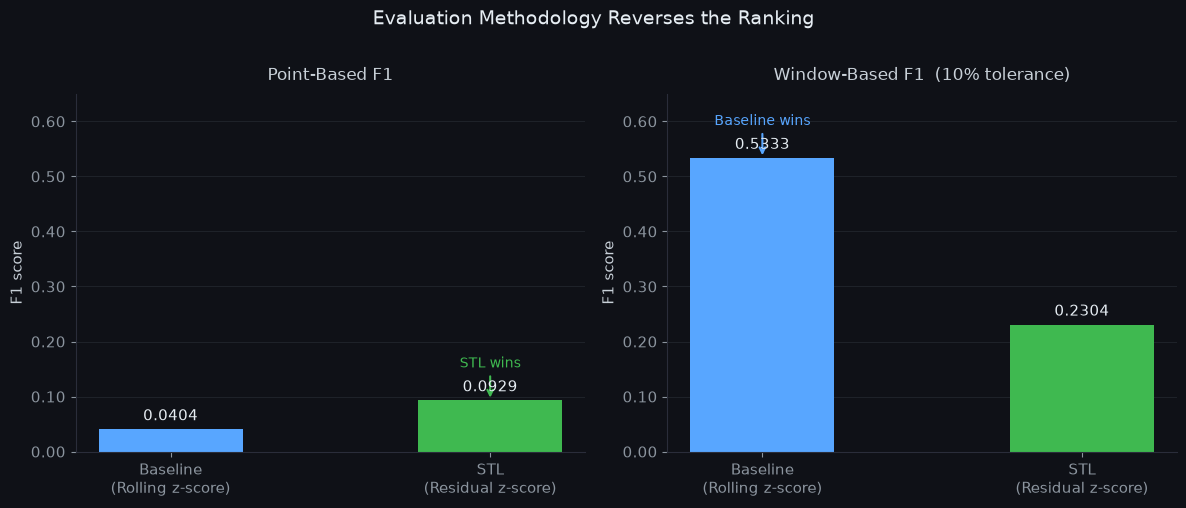

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Evaluation Methodology Reverses the Ranking',
             fontsize=14, color='#e6edf3', y=1.01)

methods = ['Baseline\n(Rolling z-score)', 'STL\n(Residual z-score)']
colors  = [C_BASE, C_STL]

# ── left: point-based ──────────────────────────────────────────────────────
ax = axes[0]
vals = [b_pt['F1'], s_pt['F1']]
bars = ax.bar(methods, vals, color=colors, width=0.45,
              linewidth=0, zorder=2)
ax.set_ylim(0, 0.65)
ax.set_title('Point-Based F1', fontsize=12, pad=10)
ax.set_ylabel('F1 score')
ax.grid(axis='y', zorder=1)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# winner annotation
ax.annotate('STL wins', xy=(1, vals[1]), xytext=(1, vals[1] + 0.06),
            ha='center', fontsize=10, color=C_STL,
            arrowprops=dict(arrowstyle='->', color=C_STL, lw=1.5))
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
            f'{v:.4f}', ha='center', va='bottom', fontsize=11, color='#e6edf3')

# ── right: window-based ────────────────────────────────────────────────────
ax = axes[1]
vals = [b_win['F1'], s_win['F1']]
bars = ax.bar(methods, vals, color=colors, width=0.45,
              linewidth=0, zorder=2)
ax.set_ylim(0, 0.65)
ax.set_title('Window-Based F1  (10% tolerance)', fontsize=12, pad=10)
ax.set_ylabel('F1 score')
ax.grid(axis='y', zorder=1)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.annotate('Baseline wins', xy=(0, vals[0]), xytext=(0, vals[0] + 0.06),
            ha='center', fontsize=10, color=C_BASE,
            arrowprops=dict(arrowstyle='->', color=C_BASE, lw=1.5))
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
            f'{v:.4f}', ha='center', va='bottom', fontsize=11, color='#e6edf3')

fig.tight_layout()
plt.savefig('../visualizations/04_f1_comparison.png',
            dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()

---
## 7. Conclusion

### Numbers

| Metric | Baseline (point) | STL (point) | Baseline (window) | STL (window) |
|---|---:|---:|---:|---:|
| Precision | 0.4000 | 0.1238 | 0.4000 | 0.1302 |
| Recall | 0.0213 | 0.0744 | 0.8000 | 1.0000 |
| **F1** | **0.0404** | **0.0929** | **0.5333** | **0.2304** |
| TP | 22 pts | 77 pts | 4 / 5 wins | 5 / 5 wins |
| FP | 33 pts | 545 pts | 33 pts | 541 pts |
| FN | 1,013 pts | 958 pts | 1 / 5 wins | 0 / 5 wins |

> **Correction:** An earlier version of this notebook reported Baseline point-F1=0.0350 and window-F1=0.5084 (51 total flags). Those numbers came from a rolling window that included the current observation in its mean, making it not truly past-only despite the comment. Independent verification caught this; `shift(1)` was applied as the fix. Corrected figures: 55 flags, point-F1=0.0404, window-F1=0.5333.

### Why the rankings flip

**Point-based recall is structurally unfair to slow-onset anomalies.** Each labeled window contains ~200 points. A method that flags 6 of them scores Recall = 6/1035 ≈ 0.006 for that window — even if those 6 flags correctly signal the start of a 4-day holiday event. STL produces more total flags (622 vs 55), so it accumulates more TP points, giving it higher point-based recall and F1.

**Window-based precision is structurally unfair to noisy methods.** STL's 622 predictions include 541 points outside all tolerance zones — these count as pure false positives regardless of how many windows it detects. Baseline makes only 55 total predictions; 33 land outside zones. Under window scoring, STL's recall advantage (5/5 vs 4/5 windows) is outweighed by its precision penalty (0.13 vs 0.40).

**The evaluation method is a design choice, not a ground truth.** For operational alerting ("did we raise an alarm during this holiday?") window-based scoring matches the use case. For exact timestamp attribution ("was this specific 30-minute slot anomalous?") point-based scoring is correct. Neither metric is wrong — they measure different things.